In [13]:
from google.colab import drive
drive.mount('/content/drive')

import sys
sys.path.append('/content/drive/MyDrive/reusable_codes')

from euler import euler


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [14]:
import numpy as np
import matplotlib.pyplot as plt

#<u>Problem 1</u>
#1. Trajectories of an autonomous system: Basics

Given :

Autonomous ordinary differential equation (ODE):

dx/dt = sin(x)

We know that Equilibrium points occur when dx/dt = 0. This happens when sin(x) = 0 → x = nπ, where n is an integer.

## Stability Analysis Using Sign of dx/dt

We analyze the stability of equilibrium points by checking the **sign of dx/dt = sin(x)** just **before and just after** each fixed point.

An equilibrium point x* is defined by:

dx/dt = sin(x*) = 0  
⇒ x* = nπ, where n is an integer.


### Case 1: Equilibrium at x = 0 (and ±2π, ±4π, ...)

Consider a small neighborhood around x = 0.

- For x slightly less than 0 (x < 0):
  sin(x) < 0  
  ⇒ dx/dt < 0  
  ⇒ x decreases further away from 0  

- For x slightly greater than 0 (x > 0):
  sin(x) > 0  
  ⇒ dx/dt > 0  
  ⇒ x increases further away from 0  

In both cases, the trajectory moves **away** from x = 0.

Therefore:
- x = 0 is an **unstable equilibrium**

The same sign behavior repeats around x = ±2π, ±4π, etc., making them **unstable equilibria** as well.


### Case 2: Equilibrium at x = π (and ±3π, ...)

Now examine a small neighborhood around x = π.

- For x slightly less than π (x < π):
  sin(x) > 0  
  ⇒ dx/dt > 0  
  ⇒ x increases toward π  

- For x slightly greater than π (x > π):
  sin(x) < 0  
  ⇒ dx/dt < 0  
  ⇒ x decreases toward π  

In both cases, the trajectory moves **toward** x = π.

Therefore:
- x = π is a **stable equilibrium**

The same argument applies to x = ±3π, ±5π, etc., making them **stable equilibria**.

We will plot the dx/dt vs x graph to check the stability of fixed points graphically.

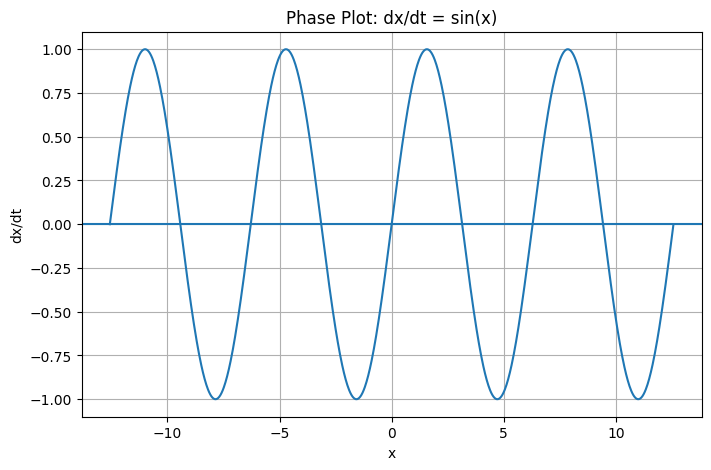

In [15]:
x = np.linspace(-4*np.pi, 4*np.pi, 1000)
dxdt = np.sin(x)

plt.figure(figsize=(8, 5))
plt.plot(x, dxdt)
plt.axhline(0)
plt.xlabel("x")
plt.ylabel("dx/dt")
plt.title("Phase Plot: dx/dt = sin(x)")
plt.grid(True)
plt.show()

In [16]:
def f(t, x):
    return np.sin(x)

We define:
- Time interval: t ∈ [0, 20]
- Time step: Δt = 0.01
- Initial conditions:
  - x(0) = -2
  - x(0) = -1
  - x(0) = 1
  - x(0) = 2

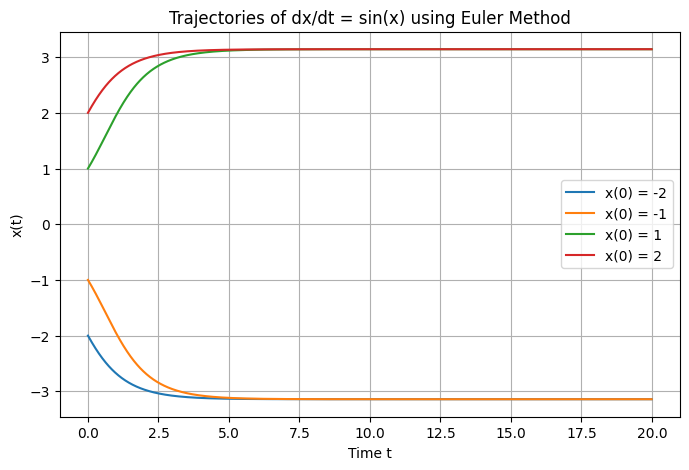

In [17]:


t = np.arange(0, 20, 0.01)

initial_conditions = [-2, -1, 1, 2]

plt.figure(figsize=(8, 5))

for x0 in initial_conditions:
    sol = euler(f, np.array([x0]), t)
    plt.plot(t, sol[:, 0], label=f"x(0) = {x0}")

plt.xlabel("Time t")
plt.ylabel("x(t)")
plt.title("Trajectories of dx/dt = sin(x) using Euler Method")
plt.legend()
plt.grid(True)
plt.show()

## Observations

From the plotted trajectories of dx/dt = sin(x) with initial conditions x(0) = -2, -1, 1, 2, we observe the following:

The solutions do not grow unbounded with time. Instead, each trajectory gradually slows down and settles toward a constant value. The positive initial conditions move upward and approach x = π, while the negative initial conditions move downward and approach x = -π. This indicates that x = ±π behave as stable fixed points because nearby trajectories converge toward them as time increases.

On the other hand, trajectories starting near x = 0 do not settle at 0. Instead, they move away from x = 0 over time. This shows that x = 0 is an unstable fixed point, since small perturbations grow and the solution diverges toward the nearest stable equilibrium.

### Key Observations

- Stable fixed points: x = ±π (and other odd multiples of π), since trajectories approach these values as t → ∞.
- Unstable fixed points: x = 0 (and other even multiples of π), since trajectories move away from these values over time.

## Asymptotic Behavior (t → ∞) and Physical Interpretation

As t → ∞, all trajectories approach the nearest stable equilibrium point (x = ±π), as seen from the graph where the curves level off to constant values. This indicates asymptotic stability at ±π and instability at x = 0.

### Physical Interpretation

The equation dx/dt = sin(x) can be interpreted as the motion of a particle in a nonlinear potential field. The sign of sin(x) determines the direction of motion:

- If sin(x) > 0, the particle moves in the positive direction.
- If sin(x) < 0, the particle moves in the negative direction.
- If sin(x) = 0, the particle is at equilibrium.

Stable equilibria (x = ±π) act like valleys: nearby trajectories move toward them and eventually settle there. Unstable equilibria (x = 0) act like peaks: even small disturbances cause the system to move away.

Thus, asymptotically, all trajectories approach the nearest stable equilibrium point, which matches both the numerical graph and the theoretical stability analysis.
